In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2

In [3]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"

x_train, y_train = readucr(root_url + "FordA_TRAIN.tsv")
x_test, y_test = readucr(root_url + "FordA_TEST.tsv")

y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(f"Train shape: {x_train.shape}")

Train shape: (3601, 500, 1)


In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
df = pd.read_csv(url, sep='\t', header=None)

print("Show examples of data:")
display(df.head(2000))

Show examples of data:


,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1,-0.050837,-0.379376,-0.657085,-0.874204,-1.023998,-1.123301,-1.170427,-1.158645,-1.072808,...,1.095010,1.359254,1.532612,1.593204,1.542711,1.392916,1.169066,0.881257,0.563154,0.221487
1996,-1,0.554742,0.655123,0.752790,0.847744,0.920995,0.969828,0.964402,0.904717,0.774494,...,1.414756,1.656212,1.832555,1.943787,1.965491,1.878676,1.661638,1.322515,0.869448,0.348556
1997,-1,-1.540809,-1.531969,-1.364001,-1.036907,-0.583101,-0.073600,0.433543,0.884403,1.232125,...,1.850951,1.998291,1.921674,1.638782,1.199710,0.660446,0.086116,-0.441655,-0.880727,-1.201928
1998,1,2.577909,2.270847,1.851404,1.373658,0.886936,0.432418,0.045211,-0.274386,-0.543576,...,0.087051,0.054018,0.025923,-0.009096,-0.071190,-0.181147,-0.348154,-0.562407,-0.779406,-0.939261


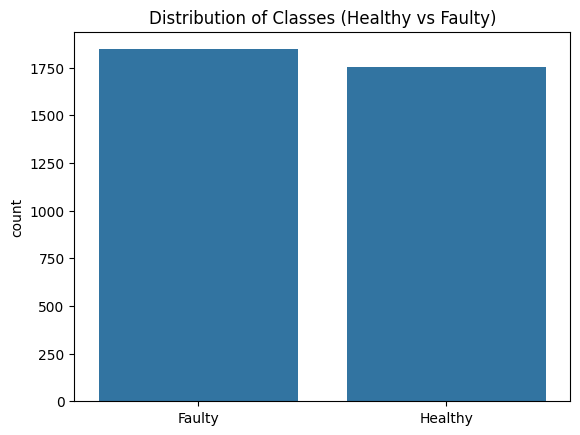

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title('Distribution of Classes (Healthy vs Faulty)')
plt.xticks([0, 1], ['Faulty', 'Healthy'])
plt.show()

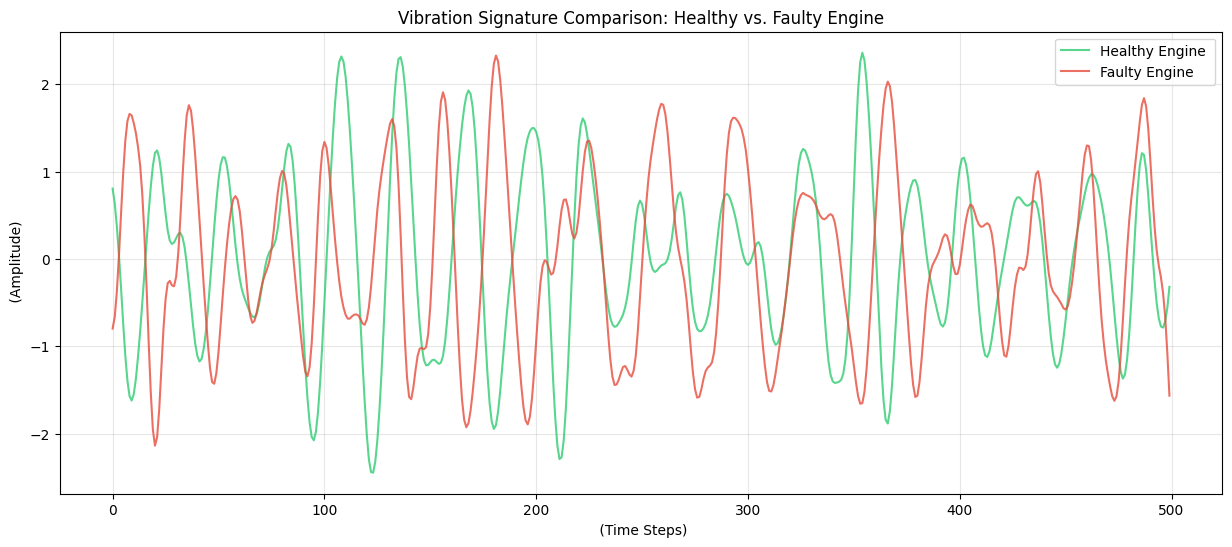

In [ ]:
import matplotlib.pyplot as plt

healthy_sample = df[df[0] == 1].iloc[0, 1:]
faulty_sample = df[df[0] == -1].iloc[0, 1:]

plt.figure(figsize=(15, 6))

plt.plot(healthy_sample.values, label='Healthy Engine ', color='#2ecc71', alpha=0.8)

plt.plot(faulty_sample.values, label='Faulty Engine ', color='#e74c3c', alpha=0.8)

plt.title("Vibration Signature Comparison: Healthy vs. Faulty Engine")
plt.xlabel(" (Time Steps)")
plt.ylabel(" (Amplitude)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"
x_train, y_train = readucr(root_url + "FordA_TRAIN.tsv")
x_test, y_test = readucr(root_url + "FordA_TEST.tsv")

y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print(" X_train_scaled و X_test_scaled ")
print(f"Shape: {X_train_scaled.shape}")

 X_train_scaled و X_test_scaled 
Shape: (3601, 500, 1)


In [ ]:
model_balanced = Sequential([
    Input(shape=(500, 1)),

    Conv1D(filters=64, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(100, dropout=0.2, recurrent_dropout=0.1),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_balanced.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_balanced = [
    ModelCheckpoint("best_model_v2.keras", save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    EarlyStopping(monitor="val_accuracy", patience=25, restore_best_weights=True)
]

history = model_balanced.fit(
    X_train_scaled, y_train,
    batch_size=32,
    epochs=150,
    validation_data=(X_test_scaled, y_test),
    callbacks=callbacks_balanced,
    verbose=1
)

_, final_acc = model_balanced.evaluate(X_test_scaled, y_test)
print(f" Accuracy: {final_acc * 100:.2f}%")

model_balanced.save('fixed_aura_model.h5')
print("   saved model  ")

Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 67s 533ms/step - accuracy: 0.6737 - loss: 0.5773 - val_accuracy: 0.5121 - val_loss: 0.7240 - learning_rate: 0.0010
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 37s 329ms/step - accuracy: 0.7987 - loss: 0.4358 - val_accuracy: 0.4659 - val_loss: 0.7206 - learning_rate: 0.0010
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 344ms/step - accuracy: 0.8112 - loss: 0.4136 - val_accuracy: 0.4788 - val_loss: 0.7700 - learning_rate: 0.0010
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - accuracy: 0.8237 - loss: 0.4047 - val_accuracy: 0.5773 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 333ms/step - accuracy: 0.8556 - loss: 0.3479 - val_accuracy: 0.8470 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - accuracy: 0.8550 - loss: 0.3378 - val_accuracy: 0.8182 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 310ms/step - accura

 Accuracy: 94.02%
   saved model  


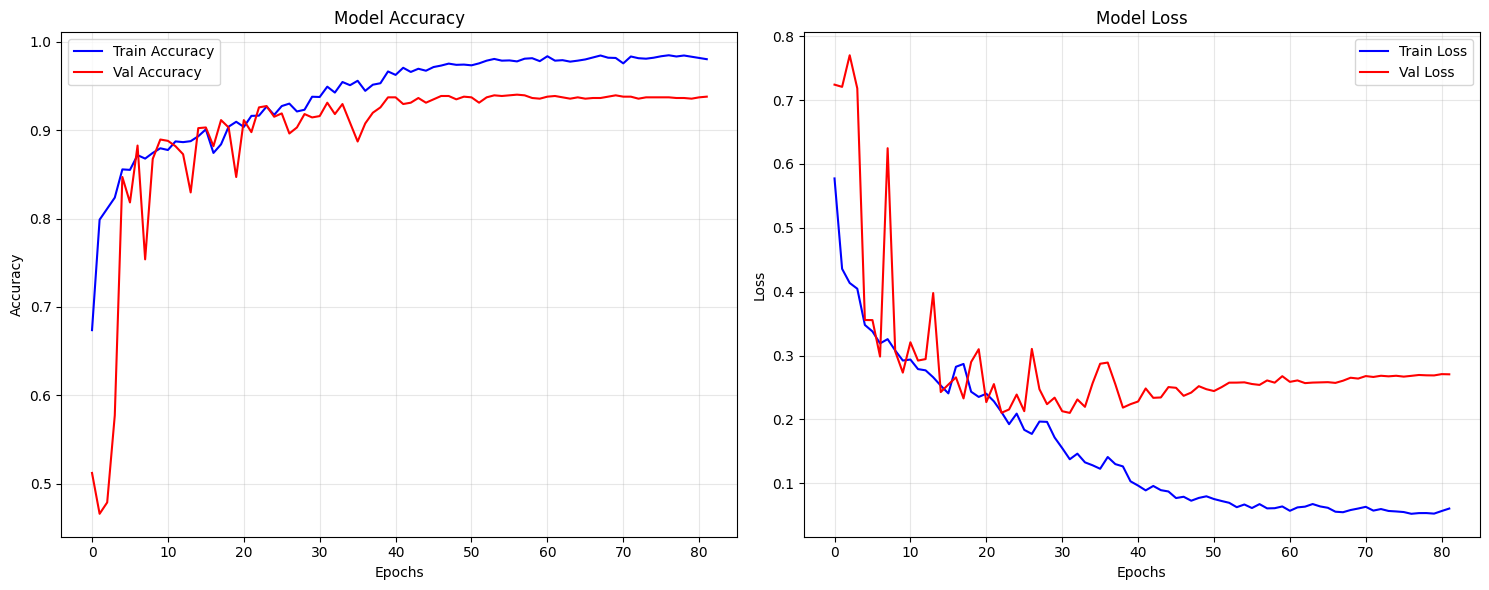

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step


<Figure size 800x600 with 0 Axes>

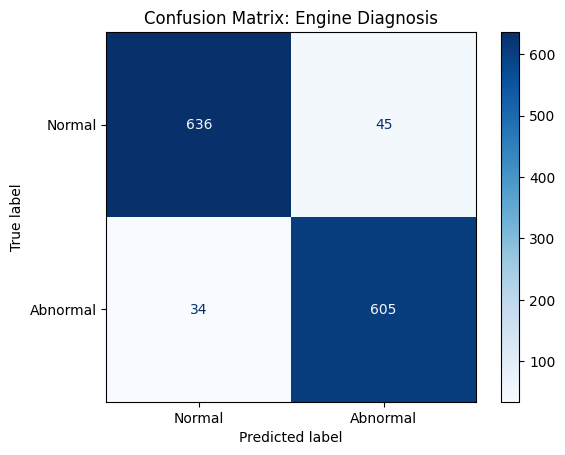


 True Positives (Abnormal detected correctly): 605
 True Negatives (Normal detected correctly): 636
 False Positives (Normal mistaken for Abnormal): 45
 False Negatives (Abnormal mistaken for Normal): 34


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_prob = model_balanced.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Engine Diagnosis')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n True Positives (Abnormal detected correctly): {tp}")
print(f" True Negatives (Normal detected correctly): {tn}")
print(f" False Positives (Normal mistaken for Abnormal): {fp}")
print(f" False Negatives (Abnormal mistaken for Normal): {fn}")

In [ ]:
loss, accuracy = model_balanced.evaluate(X_test_scaled, y_test, verbose=0)
final_acc_percentage = accuracy * 100

y_pred_prob = model_balanced.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Accuracy : {final_acc_percentage:.2f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
Accuracy : 94.02%


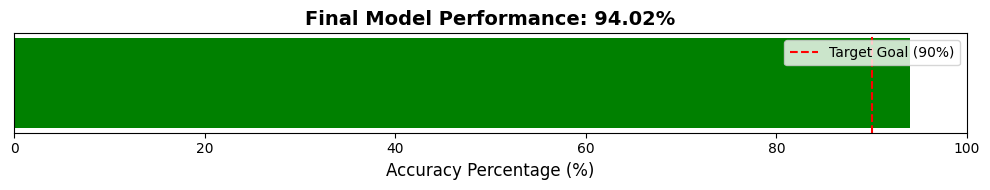

In [ ]:
import matplotlib.pyplot as plt

def plot_gauge(acc):
    fig, ax = plt.subplots(figsize=(10, 2))
    color = 'green' if acc > 90 else 'orange'
    ax.barh(0, acc, color=color, height=0.6)
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_xlabel('Accuracy Percentage (%)', fontsize=12)
    ax.set_title(f'Final Model Performance: {acc:.2f}%', fontsize=14, fontweight='bold')

    plt.axvline(x=90, color='red', linestyle='--', label='Target Goal (90%)')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_gauge(final_acc_percentage)

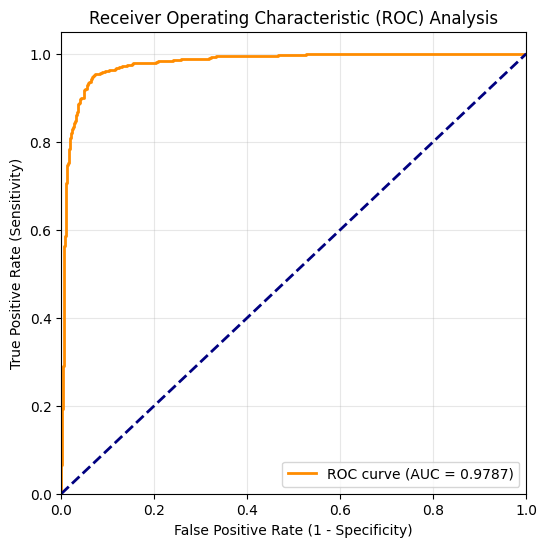

 Area Under Curve (AUC): 0.9787


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f" Area Under Curve (AUC): {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import classification_report

print("\n" + "="*50)
print("              DETAILED CLASSIFICATION REPORT              ")
print("="*50)
print(f" Accuracy Score  : {final_acc_percentage:.2f}%")
print(f" Model Loss      : {loss:.4f}")
print("-" * 50)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))
print("="*50)


              DETAILED CLASSIFICATION REPORT              
 Accuracy Score  : 94.02%
 Model Loss      : 0.2541
--------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.95      0.93      0.94       681
    Abnormal       0.93      0.95      0.94       639

    accuracy                           0.94      1320
   macro avg       0.94      0.94      0.94      1320
weighted avg       0.94      0.94      0.94      1320

